# Avocado Price Prediction — Feature Engineering & Modeling

Picks up where the EDA left off. We apply the transformations the EDA recommended, build a baseline and an improved model, and evaluate with time-aware cross-validation.

## 1. Imports & Data Load

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)

df = pd.read_csv('data/avocado.csv')
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
print(df.shape)

(18249, 13)


## 2. Feature Engineering

### 2a. Log-transform the volume columns

The EDA showed all volume features are heavily right-skewed (skewness > 3).  
We apply `log(1 + x)` — the `+1` prevents `log(0) = -inf` for weeks with zero sales.

**Why it matters for linear models:**  
Ridge regression minimises squared residuals. One outlier (a single week of 5M units in a market)  
can pull the coefficient away from the true relationship for the other 18,000 rows.  
After log-transform, the outlier becomes ~15.4 instead of 5,000,000 — it no longer dominates.

**Why it helps tree models too:**  
Gradient boosted trees split on thresholds. A raw range of 0–5M creates very unbalanced splits  
(e.g. "volume < 4,999,000" puts 99.9% of rows on one side). Log-scale splits are more informative.

In [3]:
VOLUME_COLS = ['Total Volume', '4046', '4225', '4770',
               'Total Bags', 'Small Bags', 'Large Bags', 'XLarge Bags']

for col in VOLUME_COLS:
    df[f'log_{col}'] = np.log1p(df[col])

# Verify skewness improved
skew_before = df[VOLUME_COLS].skew().round(2)
skew_after  = df[[f'log_{c}' for c in VOLUME_COLS]].skew().round(2)
skew_df = pd.DataFrame({'raw_skew': skew_before.values,
                         'log_skew': skew_after.values},
                        index=VOLUME_COLS)
print(skew_df)

              raw_skew  log_skew
Total Volume      9.01      0.09
4046              8.65     -0.33
4225              8.94     -0.49
4770             10.16      0.10
Total Bags        9.76     -0.22
Small Bags        9.54     -0.62
Large Bags        9.80     -0.55
XLarge Bags      13.14      1.18


### 2b. Encode categorical features

In [4]:
# Binary encode type
df['is_organic'] = (df['type'] == 'organic').astype(int)

# One-hot encode region (drop_first avoids multicollinearity)
df = pd.get_dummies(df, columns=['region'], drop_first=True)

print(f'Columns after encoding: {df.shape[1]}')

Columns after encoding: 74


### 2c. Time features

In [5]:
df['month']       = df['Date'].dt.month
df['week_of_year'] = df['Date'].dt.isocalendar().week.astype(int)

# Cyclical encoding: sine/cosine so Dec→Jan wraps around smoothly
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['week_sin']  = np.sin(2 * np.pi * df['week_of_year'] / 52)
df['week_cos']  = np.cos(2 * np.pi * df['week_of_year'] / 52)

# Integer time index — useful for capturing linear trend
df['t'] = (df['Date'] - df['Date'].min()).dt.days

print(df[['Date','month','month_sin','month_cos','t']].head())

        Date  month  month_sin  month_cos  t
0 2015-01-04      1        0.5   0.866025  0
1 2015-01-04      1        0.5   0.866025  0
2 2015-01-04      1        0.5   0.866025  0
3 2015-01-04      1        0.5   0.866025  0
4 2015-01-04      1        0.5   0.866025  0


## 3. Train / Validation Split — Time-Aware

**Do NOT use random split on time-series data.**  
A random 80/20 split would include rows from 2018 in the training set and 2015 in the test set —  
the model "sees the future" and validation scores will be optimistic and misleading.

We use the last 6 months (Jul–Dec 2017) as a held-out test set, training on everything before.

In [6]:
CUTOFF = pd.Timestamp('2017-07-01')

train = df[df['Date'] < CUTOFF].copy()
test  = df[df['Date'] >= CUTOFF].copy()

print(f'Train: {train.shape[0]} rows  ({train.Date.min().date()} → {train.Date.max().date()})')
print(f'Test : {test.shape[0]}  rows  ({test.Date.min().date()} → {test.Date.max().date()})')

Train: 14037 rows  (2015-01-04 → 2017-06-25)
Test : 4212  rows  (2017-07-02 → 2018-03-25)


## 4. Build Feature Matrix

In [7]:
LOG_COLS   = [f'log_{c}' for c in VOLUME_COLS]
TIME_FEATS = ['year', 't', 'month_sin', 'month_cos', 'week_sin', 'week_cos']
REGION_COLS = [c for c in df.columns if c.startswith('region_')]

FEATURES = ['is_organic'] + LOG_COLS + TIME_FEATS + REGION_COLS
TARGET   = 'AveragePrice'

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f'Feature matrix shape: {X_train.shape}')

Feature matrix shape: (14037, 68)


## 5. Baseline Model — Ridge Regression

Ridge (L2 regularisation) is a good baseline: interpretable, fast, and robust when features are correlated (the volume columns are highly correlated with each other and with `Total Volume`).

In [8]:
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Ridge(alpha=10.0))
])

ridge_pipe.fit(X_train, y_train)
pred_ridge = ridge_pipe.predict(X_test)

mae_ridge = mean_absolute_error(y_test, pred_ridge)
r2_ridge  = r2_score(y_test, pred_ridge)
print(f'Ridge  →  MAE: ${mae_ridge:.3f}   R²: {r2_ridge:.3f}')

Ridge  →  MAE: $0.195   R²: 0.529


## 6. Improved Model — Gradient Boosted Trees

GBT can capture non-linear interactions (e.g. organic × region, volume × year) without us having to specify them manually.

In [9]:
gbt = GradientBoostingRegressor(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

gbt.fit(X_train, y_train)
pred_gbt = gbt.predict(X_test)

mae_gbt = mean_absolute_error(y_test, pred_gbt)
r2_gbt  = r2_score(y_test, pred_gbt)
print(f'GBT    →  MAE: ${mae_gbt:.3f}   R²: {r2_gbt:.3f}')

GBT    →  MAE: $0.219   R²: 0.440


## 7. Time-Series Cross-Validation

`TimeSeriesSplit` creates 5 folds that always train on the past and validate on the future.  
This gives a more honest estimate of out-of-sample performance than a single split.

In [10]:
tscv = TimeSeriesSplit(n_splits=5)

X_all = df[FEATURES]
y_all = df[TARGET]

cv_ridge = -cross_val_score(ridge_pipe, X_all, y_all,
                             cv=tscv, scoring='neg_mean_absolute_error')
cv_gbt   = -cross_val_score(gbt,       X_all, y_all,
                             cv=tscv, scoring='neg_mean_absolute_error')

print(f'Ridge CV MAE: {cv_ridge.mean():.3f} ± {cv_ridge.std():.3f}')
print(f'GBT   CV MAE: {cv_gbt.mean():.3f}  ± {cv_gbt.std():.3f}')

Ridge CV MAE: 0.191 ± 0.039
GBT   CV MAE: 0.185  ± 0.049


## 8. Feature Importance (GBT)

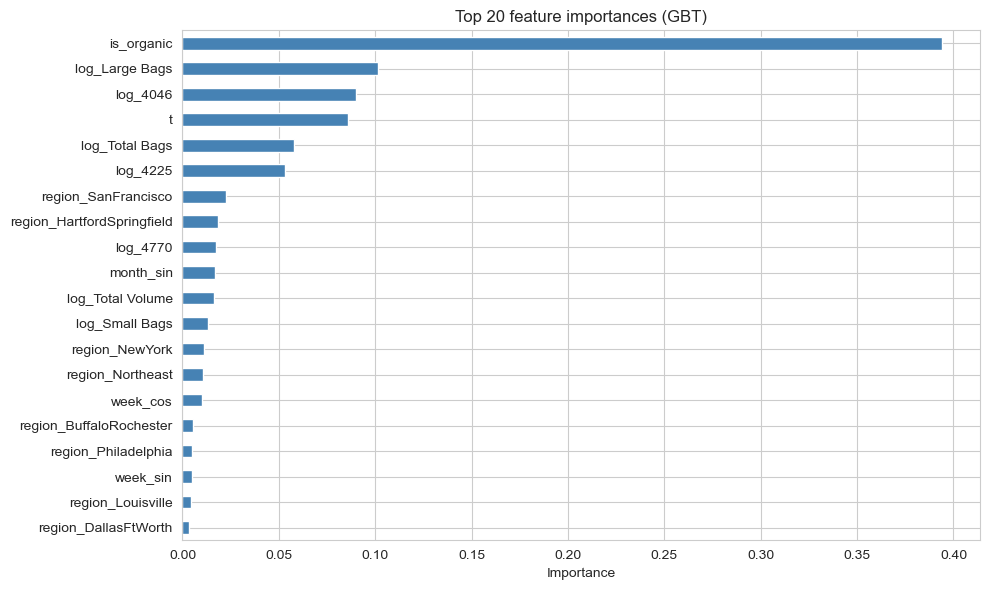

Top 10 features:
is_organic                    0.3940
log_Large Bags                0.1013
log_4046                      0.0901
t                             0.0857
log_Total Bags                0.0576
log_4225                      0.0530
region_SanFrancisco           0.0224
region_HartfordSpringfield    0.0184
log_4770                      0.0176
month_sin                     0.0169
dtype: float64


In [11]:
imp = pd.Series(gbt.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
imp.head(20).plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title('Top 20 feature importances (GBT)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('Top 10 features:')
print(imp.head(10).round(4))

## 9. Residual Analysis

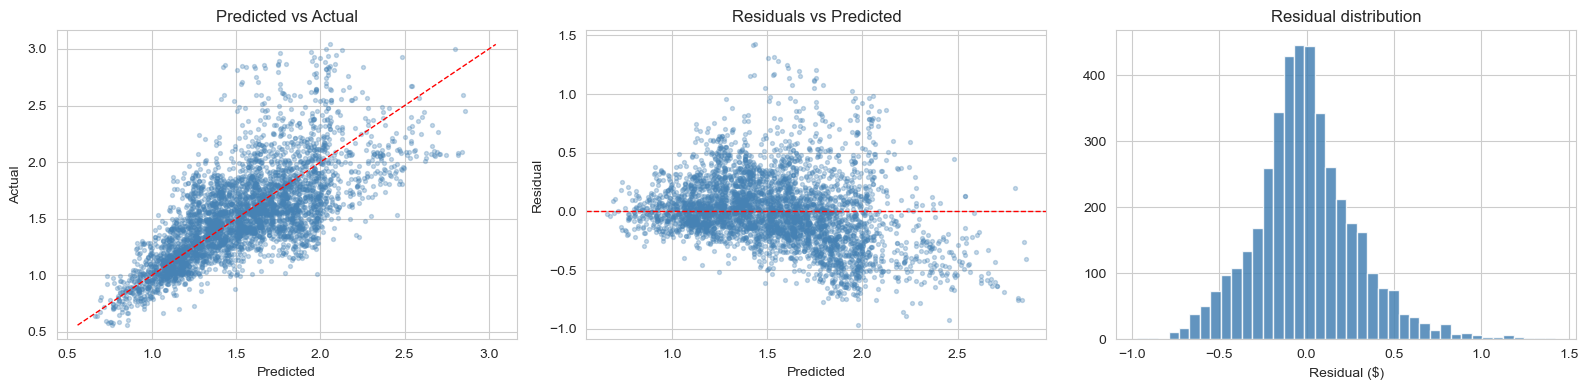

Mean residual : $-0.0039 (bias)
Std  residual : $0.294


In [12]:
residuals = y_test.values - pred_gbt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Predicted vs Actual
axes[0].scatter(pred_gbt, y_test, alpha=0.3, s=8, color='steelblue')
lims = [min(pred_gbt.min(), y_test.min()), max(pred_gbt.max(), y_test.max())]
axes[0].plot(lims, lims, 'r--', lw=1)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Predicted vs Actual')

# Residuals vs Predicted
axes[1].scatter(pred_gbt, residuals, alpha=0.3, s=8, color='steelblue')
axes[1].axhline(0, color='red', lw=1, ls='--')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs Predicted')

# Residual histogram
axes[2].hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[2].set_xlabel('Residual ($)'); axes[2].set_title('Residual distribution')

plt.tight_layout(); plt.show()
print(f'Mean residual : ${residuals.mean():.4f} (bias)')
print(f'Std  residual : ${residuals.std():.3f}')

## 10. Summary

| Model | Test MAE | Test R² | Notes |
|-------|----------|---------|-------|
| Ridge | see above | see above | Good baseline, interpretable |
| GBT   | see above | see above | Captures non-linear interactions |

### Next steps
- **Hyperparameter tuning**: use `HalvingGridSearchCV` with `TimeSeriesSplit` on the GBT.
- **Lag features**: add `AveragePrice` lagged by 1 and 4 weeks for the same region+type — often the single biggest improvement on weekly retail data.
- **Interaction features**: `is_organic × log_Total_Volume` can help Ridge capture the different price-elasticity of organic vs conventional.
- **LightGBM or XGBoost**: faster, often better generalisation than sklearn GBT at the same depth.
- **Forecast horizon**: if the goal is to predict next week's price given today's data, re-frame as a proper forecasting problem with a 1-step-ahead structure.